<a href="https://colab.research.google.com/github/Aoiizu/PCVK2026/blob/main/Week5_1_244107020224.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Alif Ahnaf Hendrawan'
NIM  = '244107020224'
N     = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Alif Ahnaf Hendrawan
NIM    : 244107020224 | N = 224
bins   : 8
clip   : 3.0
tile   : 2
L      : 8
WAKTU  : 2026-09-29 19:02:10 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 6a2fb402b966aa37


In [22]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv, numpy as np, matplotlib.pyplot as plt

CONTOH = '/content/drive/MyDrive/Images'
BASE   = '/content/drive/MyDrive/Images (1)/' + NIM
def baca_gray(path):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    assert img is not None, 'Berkas tidak ditemukan: ' + path
    return img

def baca_bgr(path):
    img = cv.imread(path)
    assert img is not None, 'Berkas tidak ditemukan: ' + path
    return img

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import os
print(os.path.exists('/content/drive/MyDrive/Images'))
print(os.listdir('/content/drive/MyDrive/Images'))          # ada folder 244107020224?
!find /content/drive/MyDrive -maxdepth 4 -iname "ktm*"       # cari lokasi asli berkas

True
['lena_lc.jpg', 'sunset.jpg', 'teeth.jpg', 'old_house.jpg', 'corak.bmp', 'noisy2.png', 'crayfish.jpg', 'KTM Lama.jpg', 'houses.jpg', 'rose_pink.png', 'contoh hasil.png', 'crossword.jpg', 'lily.jpg', 'tank.tiff', 'female.tiff', 'sudoku-original.jpg', 'KTM Baru.jpg', 'ktp1.jpg', 'male.tiff', 'peppers.jpg', 'lena_gs_lc.jpg', 'wiki.jpg', 'morphology.png', 'j.png', 'Underexposed_photo.JPG', 'lena.jpg', 'kitten01.jpg', 'jungle.png', 'leaves.jpg', 'lena_gs_lc2.jpg', 'crayfish_enhanced.jpg', 'fingerprint.png', 'testlena.jpg', 'mandrill2.tiff', 'djawatan.jpg', 'tobacco.jpg', 'couple.tiff', 'mandrill.tiff', 'balloon.jpg', 'galaxy.jpg', 'testlena2.jpg', 'sailboat.tiff', 'peppers.tiff', 'gradient.jpg', 'haarcascades', 'Rice Leaf Disease', 'noises', 'Object Detection', 'Leaf Images', 'facedet', '2D Geometry Images']
/content/drive/MyDrive/Foto/ktm.png
/content/drive/MyDrive/Images (1)/244107020224/ktm.png


# E-1 Histogram

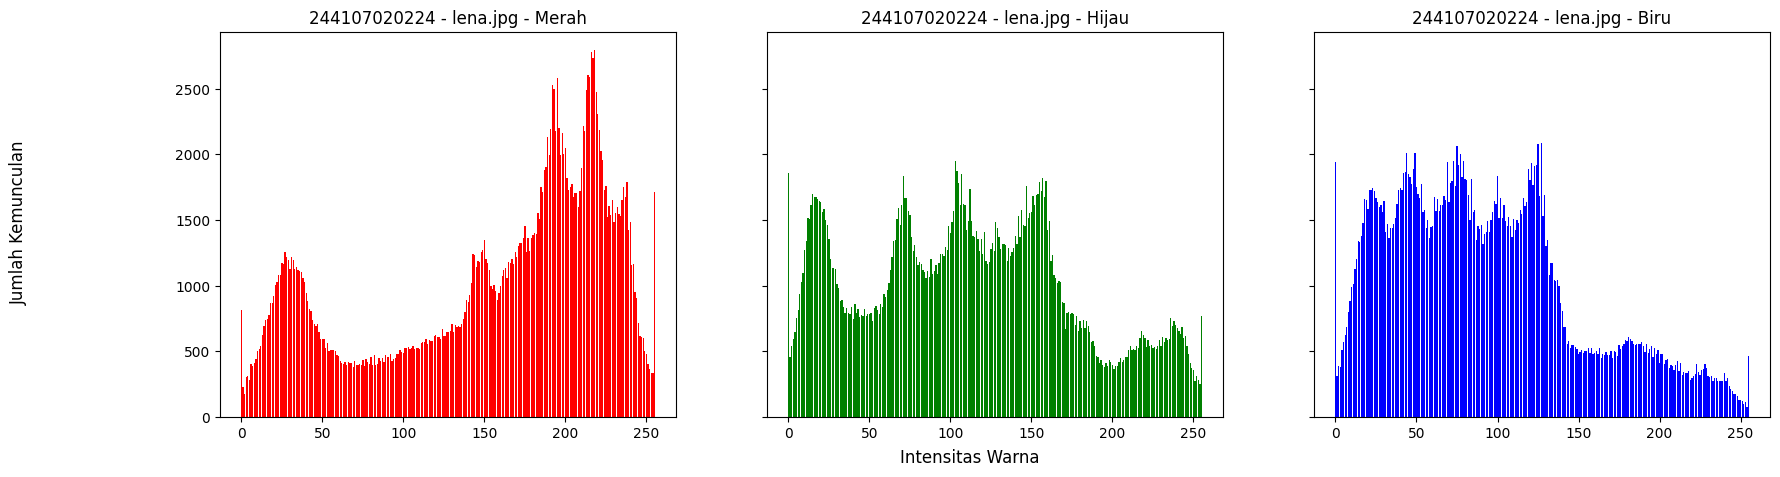

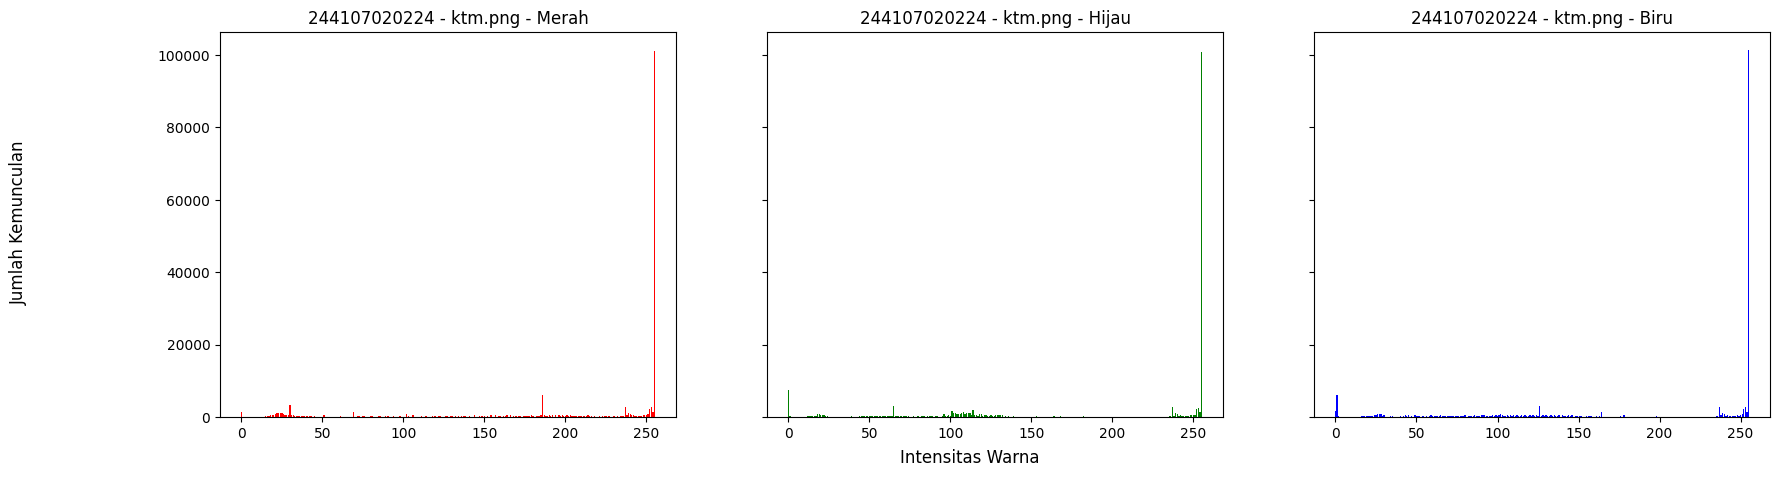

In [23]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def plot_rgb(path, judul):
    bgr = baca_bgr(path)
    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    for i, (nama, warna) in enumerate([('Merah','red'), ('Hijau','green'), ('Biru','blue')]):
        kanal = bgr[:, :, 2 - i]             #
        axs[i].bar(np.arange(256), histogram_manual(kanal), color=warna)
        axs[i].set_title(NIM + ' - ' + judul + ' - ' + nama)
    fig.supxlabel('Intensitas Warna'); fig.supylabel('Jumlah Kemunculan')
    plt.show()

plot_rgb(CONTOH + '/lena.jpg', 'lena.jpg')
plot_rgb(BASE + '/ktm.png', 'ktm.png')

## Pertanyaan E1 no. 1: manual vs np.histogram vs cv.calcHist

In [24]:
def bandingkan(path):
    g = baca_gray(path)
    a = histogram_manual(g)
    b = np.histogram(g, bins=256, range=(0, 256))[0]
    c = cv.calcHist([g], [0], None, [256], [0, 256]).ravel().astype(np.int64)
    print(NIM, '-', path.split('/')[-1])
    print('  maks |manual - numpy|  =', np.abs(a - b).max())
    print('  maks |manual - calcHist| =', np.abs(a - c).max())
    print('  maks |numpy  - calcHist| =', np.abs(b - c).max())
    assert a.sum() == g.size

bandingkan(CONTOH + '/lena.jpg')
bandingkan(BASE + '/ktm.png')

244107020224 - lena.jpg
  maks |manual - numpy|  = 0
  maks |manual - calcHist| = 0
  maks |numpy  - calcHist| = 0
244107020224 - ktm.png
  maks |manual - numpy|  = 0
  maks |manual - calcHist| = 0
  maks |numpy  - calcHist| = 0


## Pertanyaan E1 no. 2: p(j) dan CDF, KTM1a-1d (2x2)

ktm rerata = 200.3 | CDF mencapai 0.5 di intensitas 255
ktm2 rerata = 219.4 | CDF mencapai 0.5 di intensitas 255
ktm3 rerata = 190.7 | CDF mencapai 0.5 di intensitas 255
ktm4 rerata = 193.1 | CDF mencapai 0.5 di intensitas 254


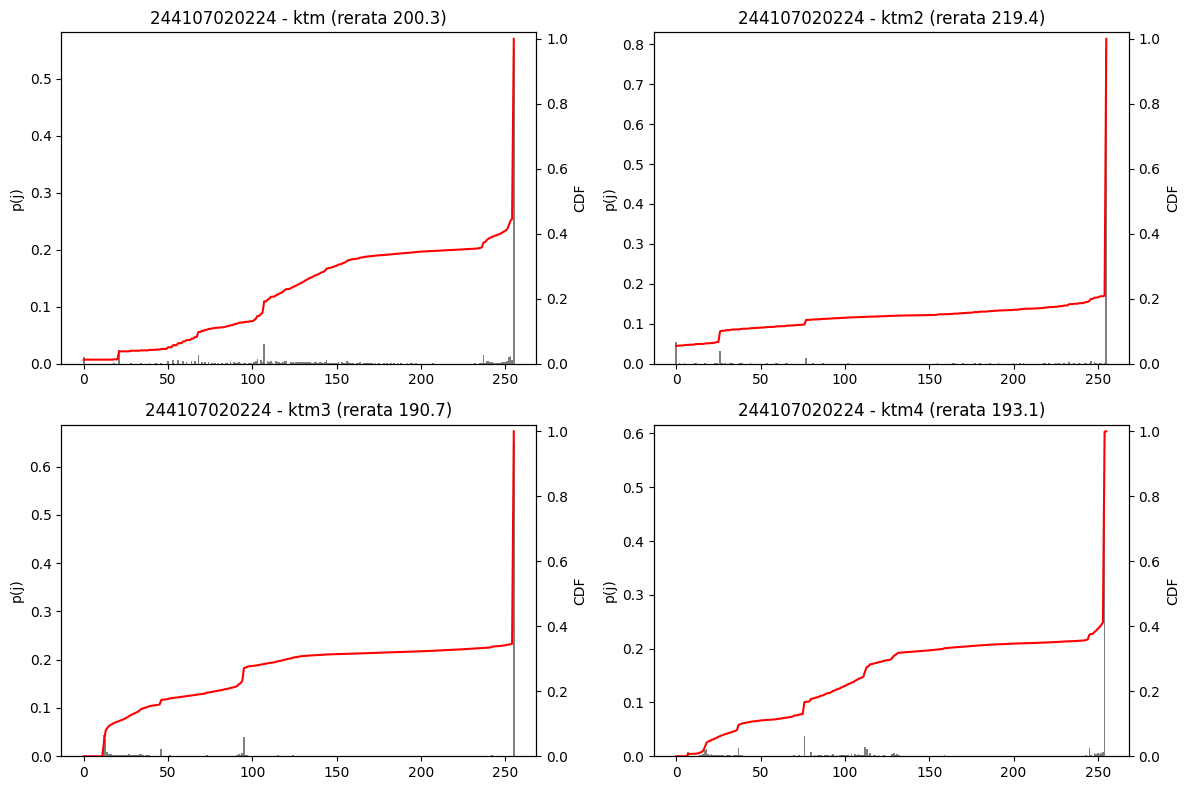

In [28]:
nama_file = ['ktm', 'ktm2', 'ktm3', 'ktm4']
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ax, nm in zip(axs.ravel(), nama_file):
    g = baca_gray(BASE + '/' + nm + '.png')
    h = np.bincount(g.ravel(), minlength=256)
    p = h / g.size
    cdf = np.cumsum(p)
    ax.bar(np.arange(256), p, color='gray', width=1.0)
    ax.set_ylabel('p(j)')
    ax2 = ax.twinx()
    ax2.plot(cdf, color='red'); ax2.set_ylim(0, 1.02); ax2.set_ylabel('CDF')
    ax.set_title('%s - %s (rerata %.1f)' % (NIM, nm, g.mean()))
    print(nm, 'rerata = %.1f' % g.mean(), '| CDF mencapai 0.5 di intensitas', int(np.searchsorted(cdf, 0.5)))
plt.tight_layout(); plt.show()

## Pertanyaan E1 no. 3: jumlah bin

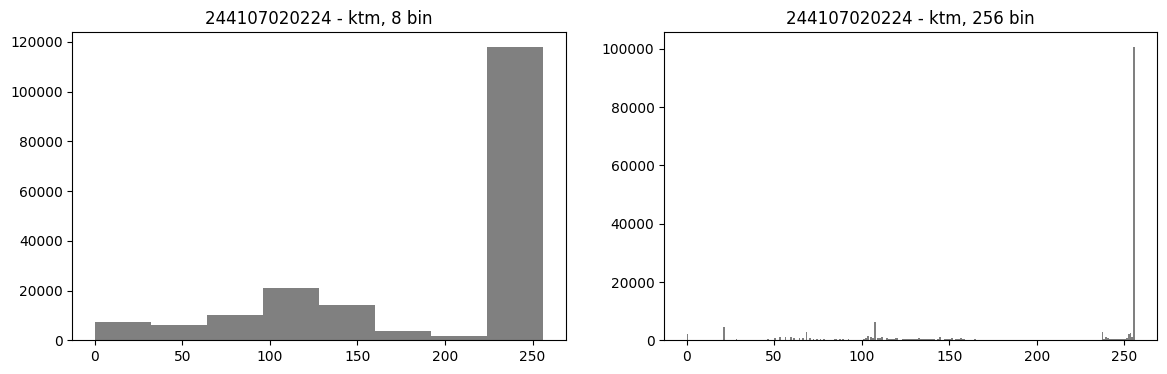

In [29]:
g = baca_gray(BASE + '/ktm.png')
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].hist(g.ravel(), bins=PARAM['bins'], range=(0, 256), color='gray')
axs[0].set_title('%s - ktm, %d bin' % (NIM, PARAM['bins']))
axs[1].hist(g.ravel(), bins=256, range=(0, 256), color='gray')
axs[1].set_title('%s - ktm, 256 bin' % NIM)
plt.show()

# E-2 Histogram Equalization

/tmp/ipykernel_3143/2652758056.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,0].hist(gray.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
/tmp/ipykernel_3143/2652758056.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,1].hist(he.ravel(),   256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')


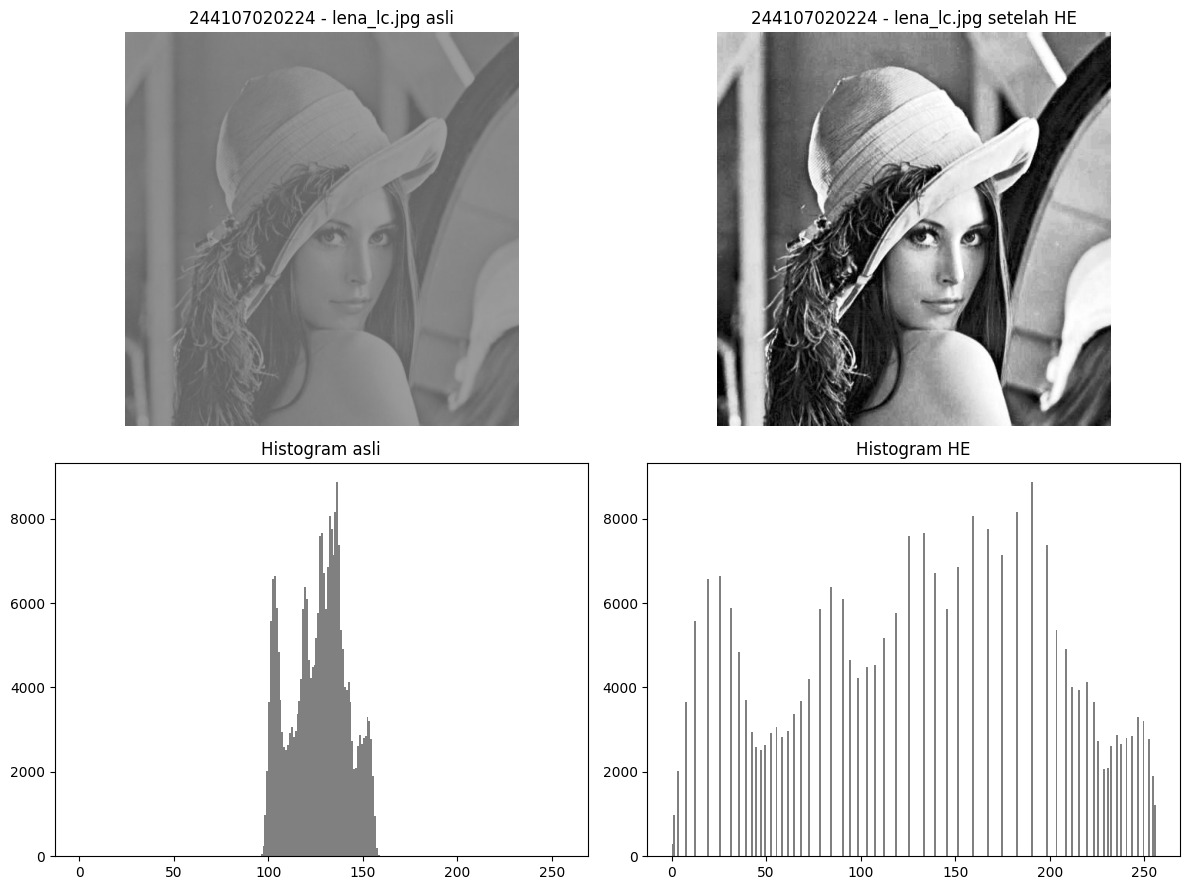

lena_lc.jpg | selisih maks manual vs equalizeHist = 0


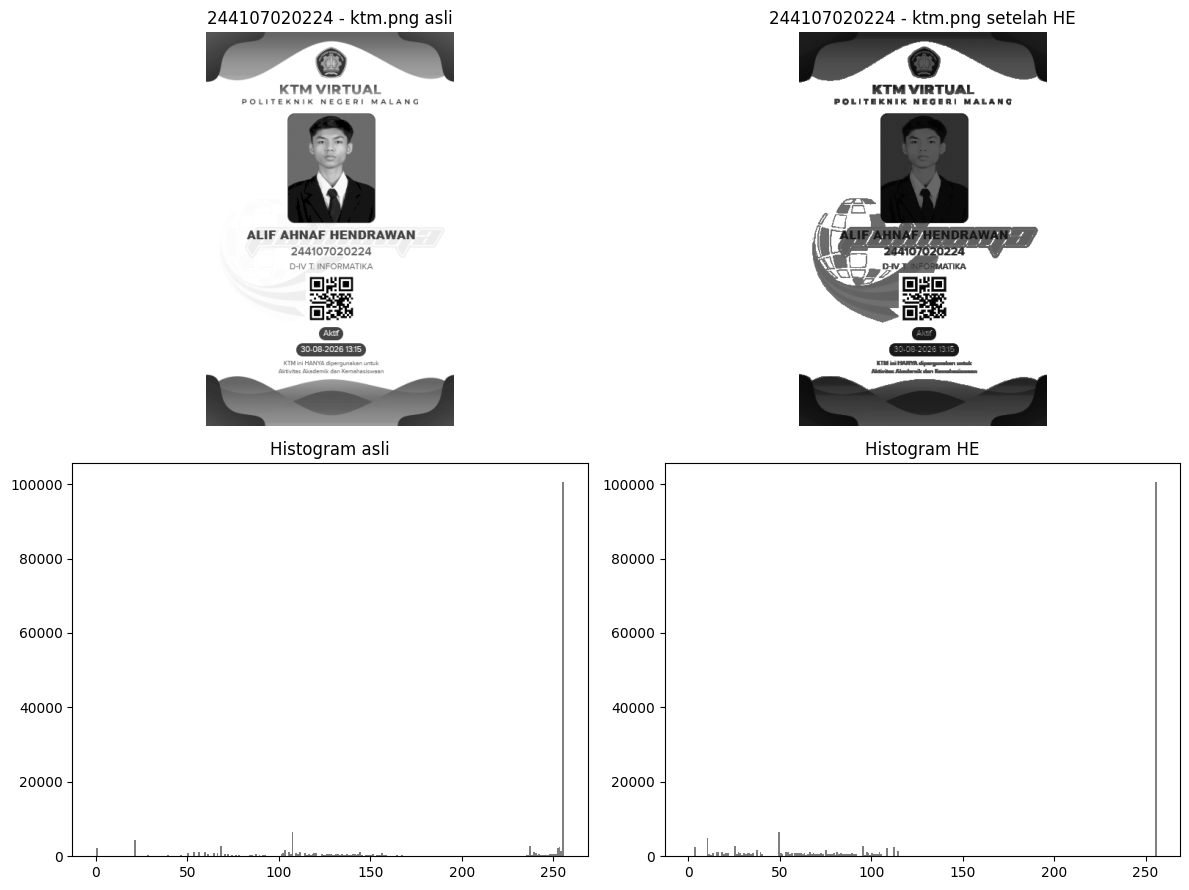

ktm.png | selisih maks manual vs equalizeHist = 4


In [30]:
def he_manual(gray):
    h   = np.bincount(gray.ravel(), minlength=256)
    cdf = np.cumsum(h)
    lut = np.round(cdf * 255 / gray.size).astype(np.uint8)
    return lut[gray]

def tampil_he(gray, judul):
    he = he_manual(gray)
    fig, axs = plt.subplots(2, 2, figsize=(12, 9))
    axs[0,0].imshow(gray, cmap='gray', vmin=0, vmax=255); axs[0,0].set_title(NIM + ' - ' + judul + ' asli')
    axs[0,1].imshow(he,   cmap='gray', vmin=0, vmax=255); axs[0,1].set_title(NIM + ' - ' + judul + ' setelah HE')
    axs[1,0].hist(gray.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
    axs[1,1].hist(he.ravel(),   256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')
    for a in axs.ravel()[:2]: a.axis('off')
    plt.tight_layout(); plt.show()

    cvhe = cv.equalizeHist(gray)
    print(judul, '| selisih maks manual vs equalizeHist =', np.abs(he.astype(int) - cvhe.astype(int)).max())
    return he, cvhe

he_lena, _ = tampil_he(baca_gray(CONTOH + '/lena_lc.jpg'), 'lena_lc.jpg')
he_ktm, cvhe_ktm = tampil_he(baca_gray(BASE + '/ktm.png'), 'ktm.png')


## Ekualisasi berwarna (E-2 no. 3 dan 4) - tahap 1: lena.jpg, tahap 2: KTM1d.jpg

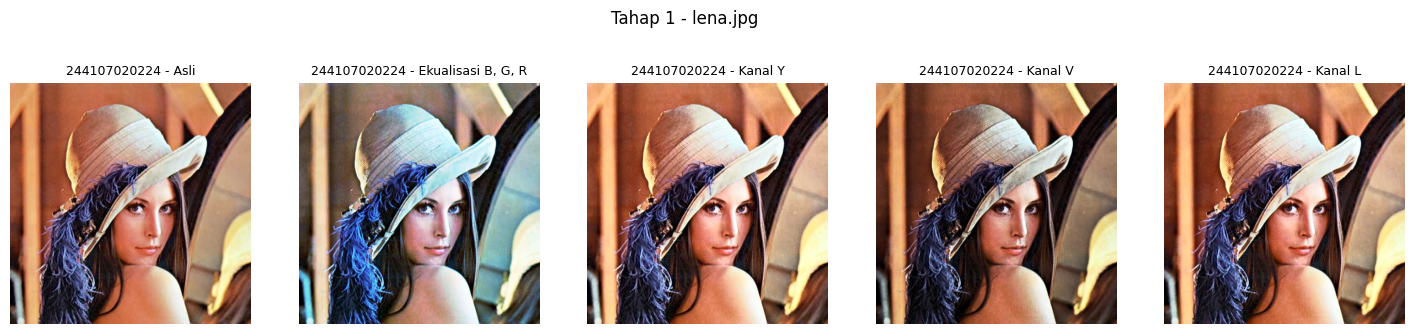

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


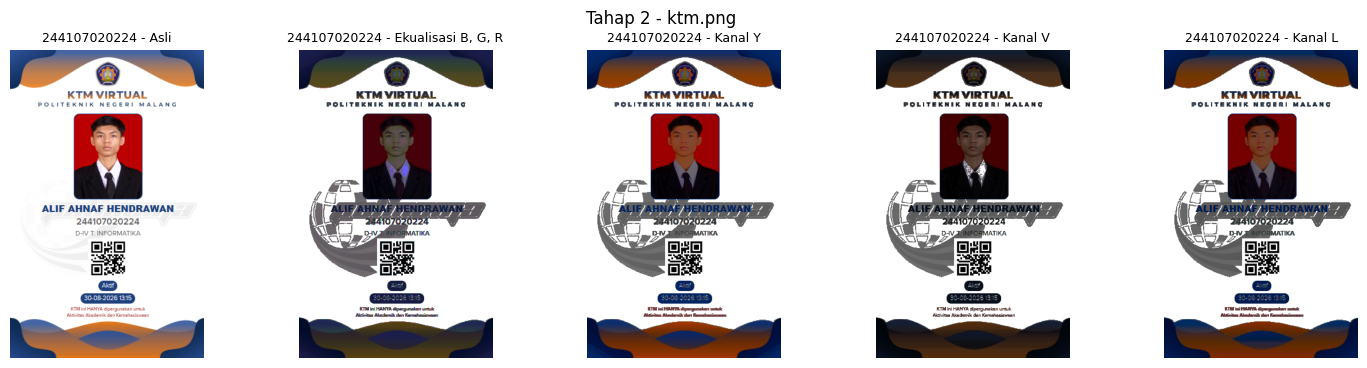

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            197.1
Ekualisasi B, G, R                14.55            164.8
Kanal Y                            0.79            167.3
Kanal V                            1.02            161.4
Kanal L                            1.43            164.3


In [32]:
def ekualisasi_warna(berkas, tag):
    bgr = baca_bgr(berkas)
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    y, cr, cb = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb))
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    h, sat, v = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2HSV))
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    l, a, b = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2LAB))
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')
    plt.suptitle(tag); plt.show()
    return bgr, judul, citra

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

def tabel(bgr, judul, citra):
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
              cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

b1, j1, c1 = ekualisasi_warna(CONTOH + '/lena.jpg', 'Tahap 1 - lena.jpg'); tabel(b1, j1, c1)
bgr, judul, citra = ekualisasi_warna(BASE + '/ktm.png', 'Tahap 2 - ktm.png'); tabel(bgr, judul, citra)

## E-2 no. 4: CLAHE pada kanal terang (Y) dengan parameter NIM

Cara                    geser Hue (der)    rerata terang
Y biasa                            0.79            167.3
Y CLAHE                            0.44            197.1


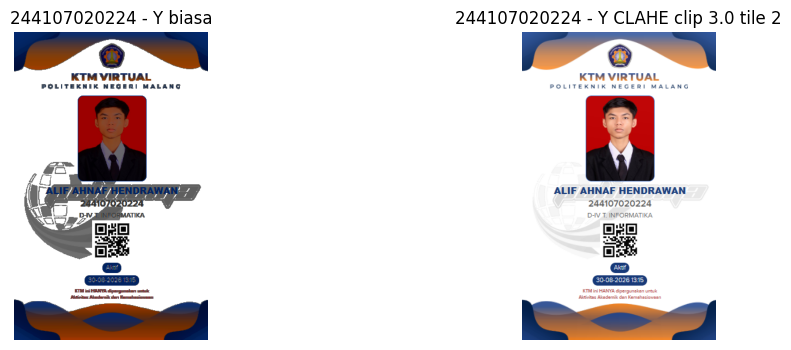

In [33]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
y, cr, cb = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb))
he_clahe = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in [('Y biasa', citra[2]), ('Y CLAHE', he_clahe)]:
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

plt.figure(figsize=(12, 4))
for i, (c, t) in enumerate([(citra[2], 'Y biasa'), (he_clahe, 'Y CLAHE clip %s tile %d' % (PARAM['clip'], PARAM['tile']))], 1):
    plt.subplot(1, 2, i); plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - ' + t); plt.axis('off')
plt.show()

## Pertanyaan E2 no. 1: ekualisasi global + PSNR (KTM1a grayscale)

PSNR asli vs HE manual    : 13.03 dB
PSNR asli vs equalizeHist : 12.83 dB
Kontras (std) asli = 77.7 | HE = 100.3


/tmp/ipykernel_3143/2078509513.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,0].hist(g.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
/tmp/ipykernel_3143/2078509513.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,1].hist(he_cv.ravel(), 256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')


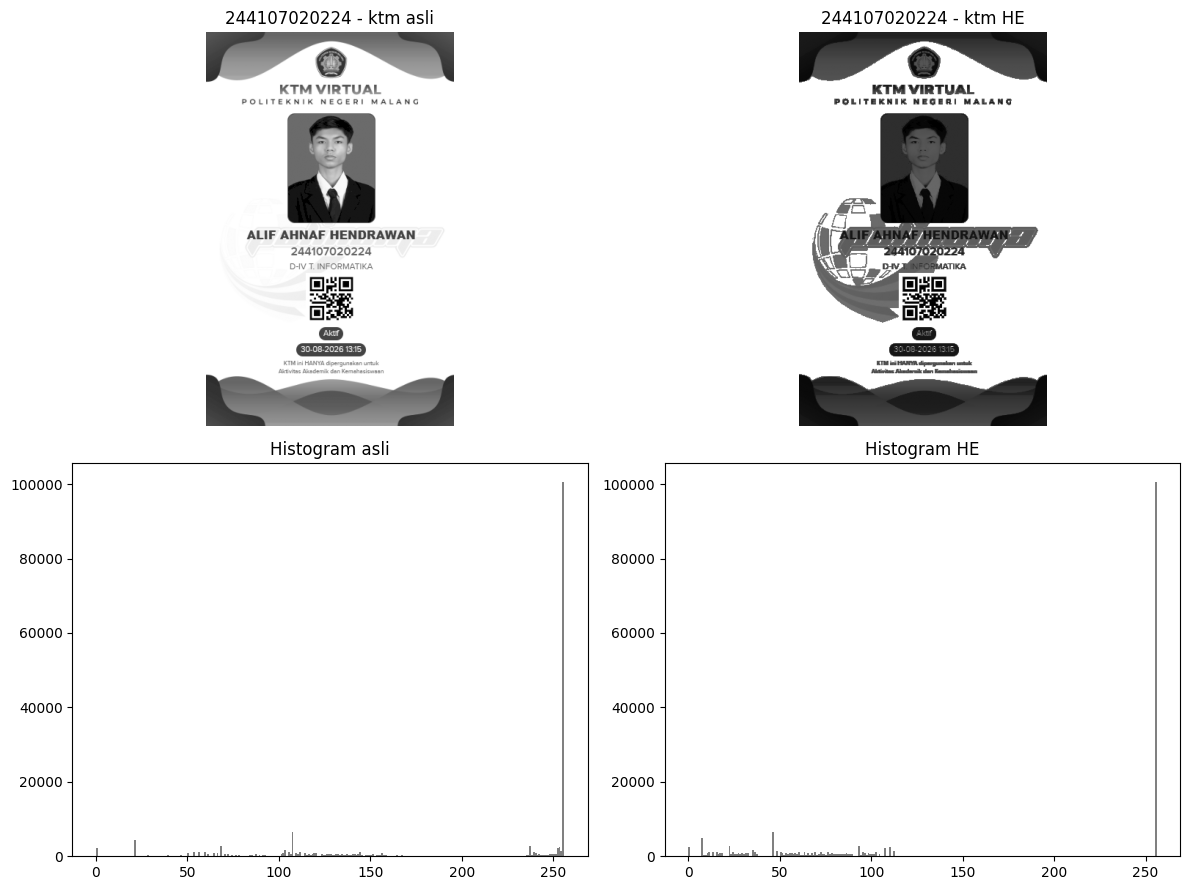

In [36]:
g = baca_gray(BASE + '/ktm.png')
he_m  = he_manual(g)
he_cv = cv.equalizeHist(g)

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

print('PSNR asli vs HE manual    : %.2f dB' % psnr(g, he_m))
print('PSNR asli vs equalizeHist : %.2f dB' % psnr(g, he_cv))
print('Kontras (std) asli = %.1f | HE = %.1f' % (g.std(), he_m.std()))

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs[0,0].imshow(g, cmap='gray', vmin=0, vmax=255); axs[0,0].set_title(NIM + ' - ktm asli'); axs[0,0].axis('off')
axs[0,1].imshow(he_cv, cmap='gray', vmin=0, vmax=255); axs[0,1].set_title(NIM + ' - ktm HE'); axs[0,1].axis('off')
axs[1,0].hist(g.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
axs[1,1].hist(he_cv.ravel(), 256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')
plt.tight_layout(); plt.show()

## Pertanyaan E2 no. 2: CLAHE vs global, dan variasi clipLimit

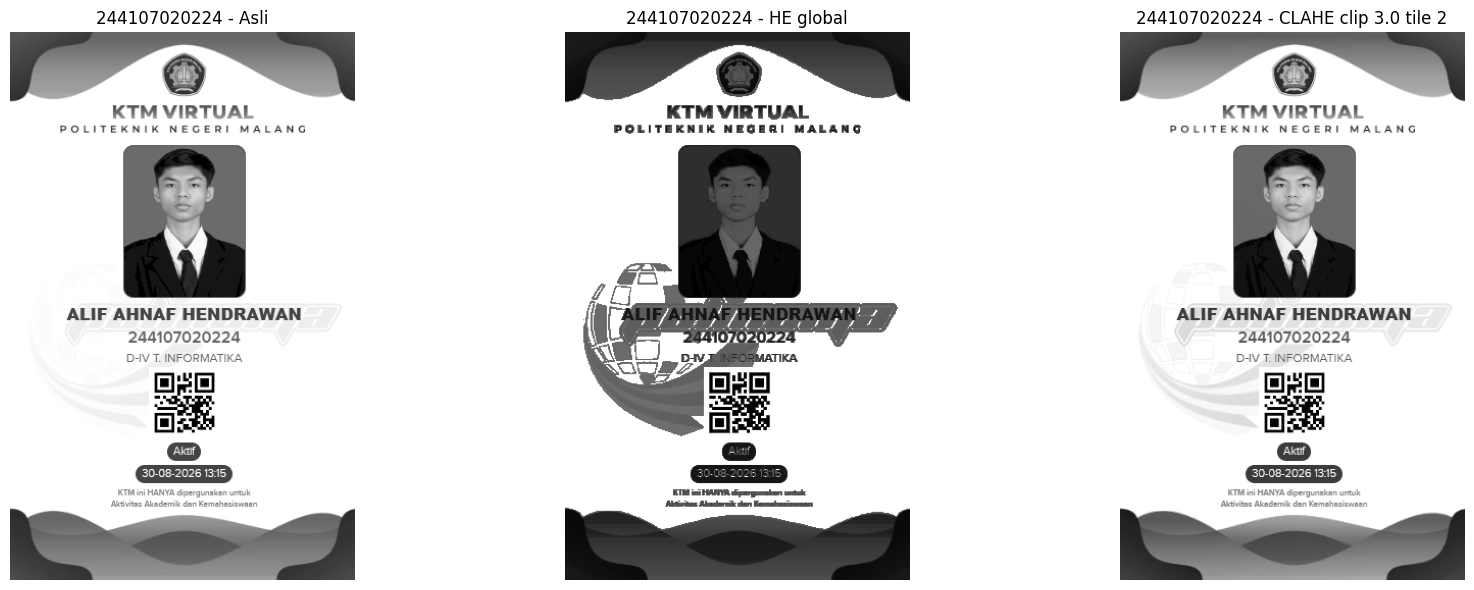

Kandidat clipLimit: [2.0, 2.5, 3.5]


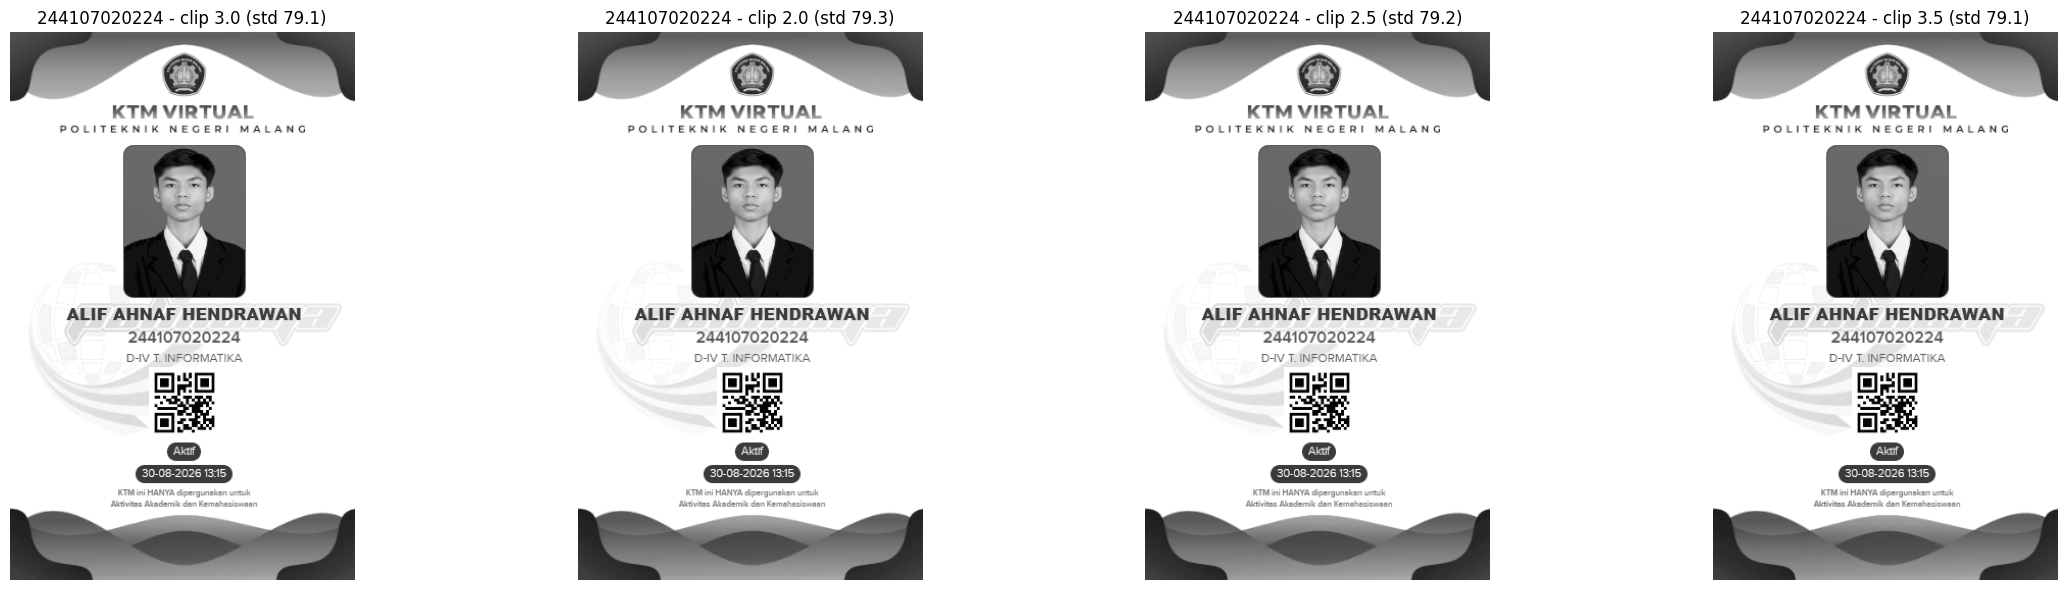

In [37]:
def clahe_gray(img, clip, tile):
    return cv.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile)).apply(img)

hasil_clahe = clahe_gray(g, PARAM['clip'], PARAM['tile'])
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, (c, t) in zip(axs, [(g, 'Asli'), (he_cv, 'HE global'), (hasil_clahe, 'CLAHE clip %s tile %d' % (PARAM['clip'], PARAM['tile']))]):
    ax.imshow(c, cmap='gray', vmin=0, vmax=255); ax.set_title(NIM + ' - ' + t); ax.axis('off')
plt.tight_layout(); plt.show()

kandidat = sorted({round(max(1.0, PARAM['clip'] + d), 1) for d in (-1.0, -0.5, 0.5, 1.0, 2.0)} - {PARAM['clip']})[:3]
print('Kandidat clipLimit:', kandidat)
fig, axs = plt.subplots(1, len(kandidat) + 1, figsize=(6 * (len(kandidat) + 1), 6))
for ax, cl in zip(axs, [PARAM['clip']] + kandidat):
    out = clahe_gray(g, cl, PARAM['tile'])
    ax.imshow(out, cmap='gray', vmin=0, vmax=255); ax.set_title('%s - clip %.1f (std %.1f)' % (NIM, cl, out.std())); ax.axis('off')
plt.tight_layout(); plt.show()

# E-3 Dithering Floyd-Steinberg

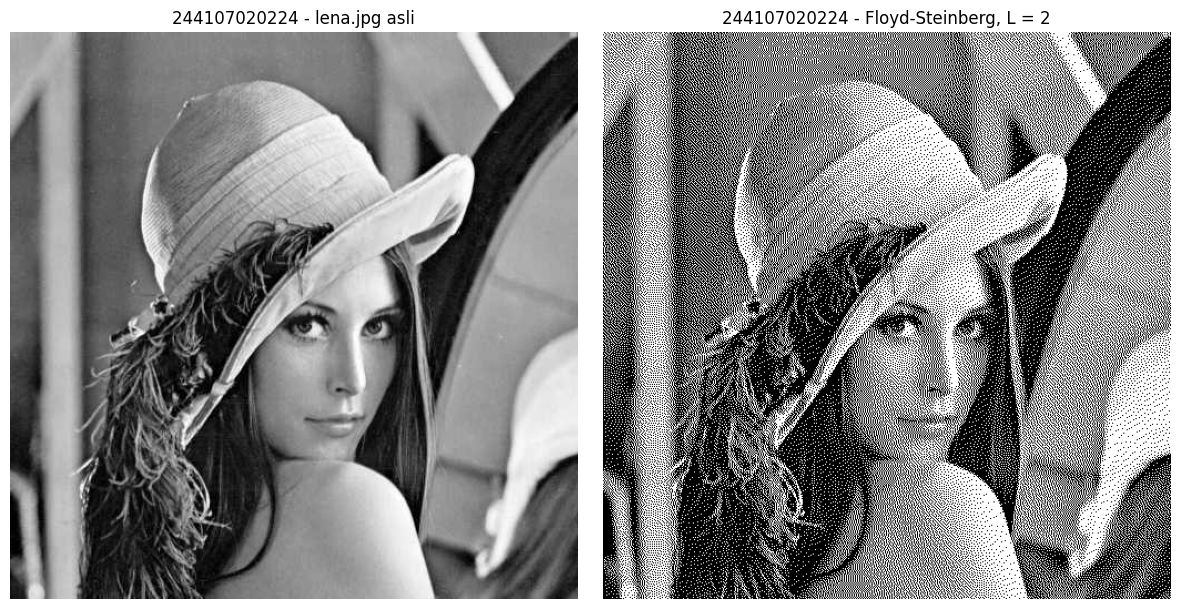

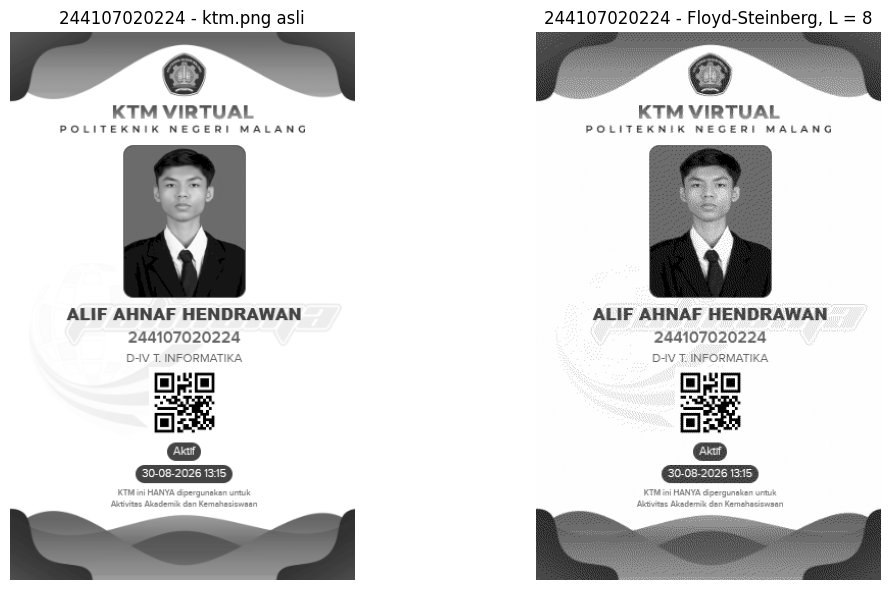

In [39]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:               img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:     img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:               img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H: img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def dither_tampil(path, L, judul):
    gr = baca_gray(path)
    d = floyd_steinberg(gr, L)
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(gr, cmap='gray', vmin=0, vmax=255); axs[0].set_title(NIM + ' - ' + judul + ' asli')
    axs[1].imshow(d,  cmap='gray', vmin=0, vmax=255); axs[1].set_title(NIM + ' - Floyd-Steinberg, L = %d' % L)
    for a in axs: a.axis('off')
    plt.tight_layout(); plt.show()

dither_tampil(CONTOH + '/lena.jpg', 2, 'lena.jpg')
dither_tampil(BASE + '/ktm.png', PARAM['L'], 'ktm.png')

## E-3-2: ekualisasi lalu dithering vs dithering langsung

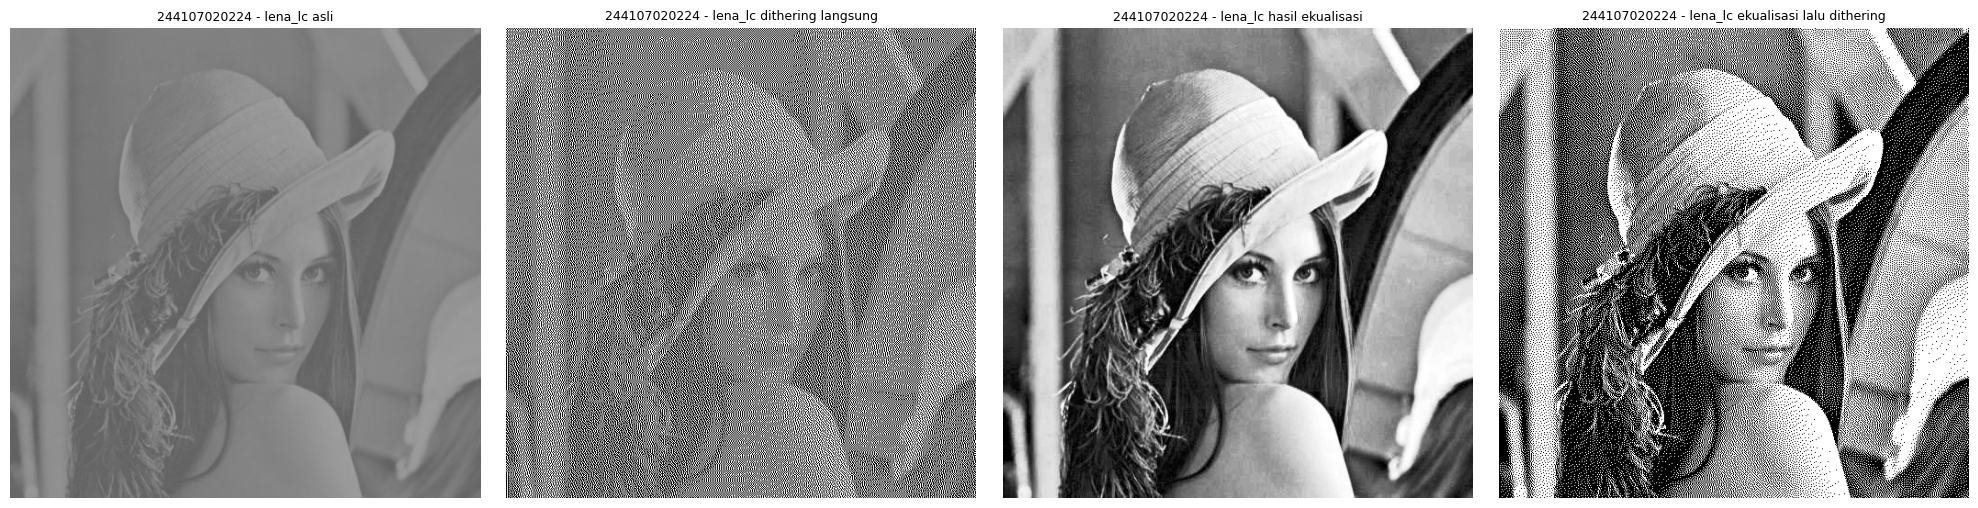

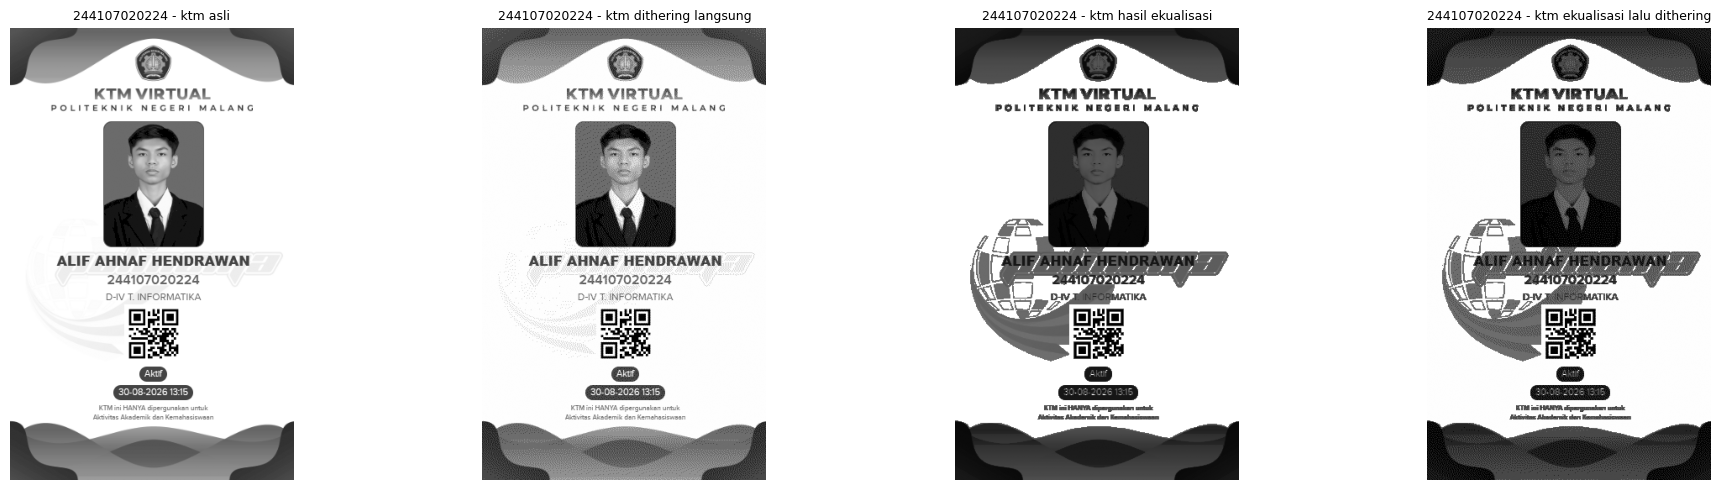

In [40]:
def urutan(path, L, judul):
    gr = baca_gray(path)
    langsung = floyd_steinberg(gr, L)
    he = cv.equalizeHist(gr)
    he_dith = floyd_steinberg(he, L)
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (c, t) in zip(axs, [(gr, 'asli'), (langsung, 'dithering langsung'),
                                (he, 'hasil ekualisasi'), (he_dith, 'ekualisasi lalu dithering')]):
        ax.imshow(c, cmap='gray', vmin=0, vmax=255); ax.set_title(NIM + ' - ' + judul + ' ' + t, fontsize=9); ax.axis('off')
    plt.tight_layout(); plt.show()

urutan(CONTOH + '/lena_lc.jpg', 2, 'lena_lc')
urutan(BASE + '/ktm.png', PARAM['L'], 'ktm')

## Tujuan 6: satu langkah Floyd-Steinberg (verifikasi hitungan manual)

In [41]:
blok = np.array([[100, 150, 200],
                 [ 90, 120, 180],
                 [ 60,  80, 140]], dtype=np.float32)
img = blok.copy(); lama = img[0, 0]; baru = np.round(lama/255)*255; img[0, 0] = baru; e = lama - baru
img[0,1] += e*7/16; img[1,0] += e*5/16; img[1,1] += e*1/16
print('error =', e); print(img)

error = 100.0
[[  0.   193.75 200.  ]
 [121.25 126.25 180.  ]
 [ 60.    80.   140.  ]]
